   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

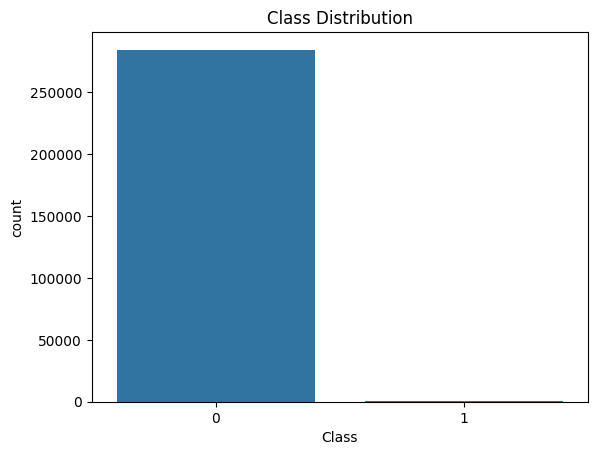


=== WITHOUT SMOTE ===
Accuracy: 0.9994733330992591
Precision: 0.9047619047619048
Recall: 0.7755102040816326
F1 Score: 0.8351648351648352

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



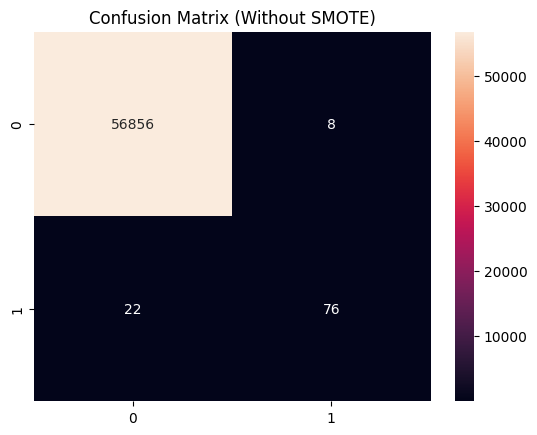

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64

=== WITH SMOTE ===
Accuracy: 0.9615708718092764
Precision: 0.038410596026490065
Recall: 0.8877551020408163
F1 Score: 0.07363520947947524

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.89      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.92      0.53     56962
weighted avg       1.00      0.96      0.98     56962



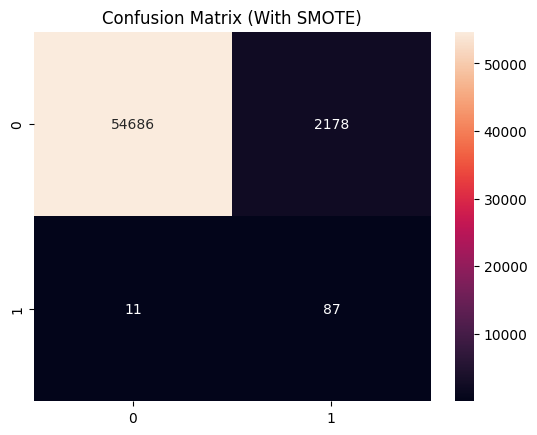

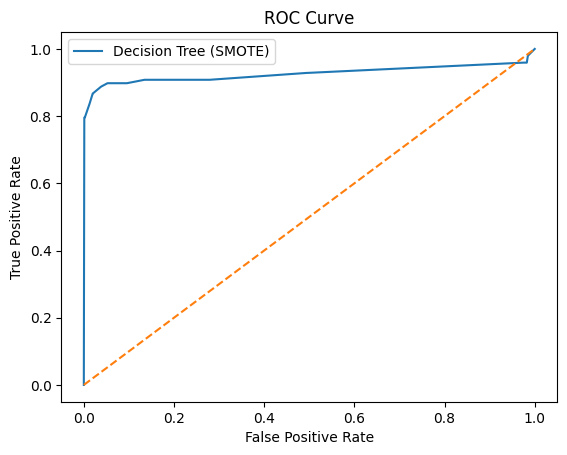

AUC Score: 0.9258119803211098


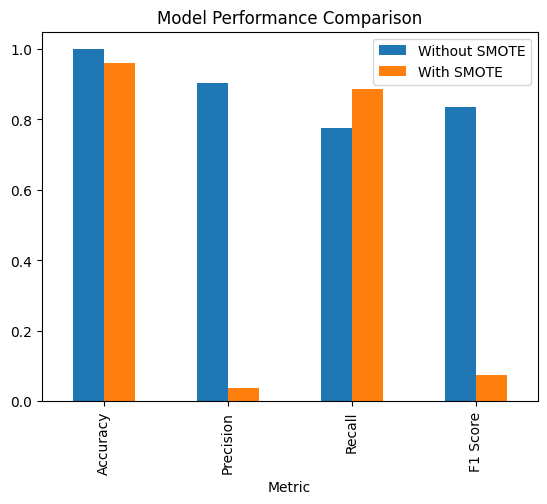

In [ ]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE


# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv('creditcard.csv')

print(df.head())
print(df.info())


# =========================
# 3. Check Class Distribution
# =========================
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()


# =========================
# 4. Feature Scaling
# =========================
scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

df.drop(['Amount', 'Time'], axis=1, inplace=True)


# =========================
# 5. Define Features & Target
# =========================
X = df.drop('Class', axis=1)
y = df['Class']


# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================
# PART A: BASELINE MODEL (WITHOUT SMOTE)
# =========================

# Train model
model_no_smote = DecisionTreeClassifier(max_depth=5, random_state=42)
model_no_smote.fit(X_train, y_train)

# Predict
y_pred_no = model_no_smote.predict(X_test)

# Metrics
acc_no = accuracy_score(y_test, y_pred_no)
prec_no = precision_score(y_test, y_pred_no)
rec_no = recall_score(y_test, y_pred_no)
f1_no = f1_score(y_test, y_pred_no)

print("\n=== WITHOUT SMOTE ===")
print("Accuracy:", acc_no)
print("Precision:", prec_no)
print("Recall:", rec_no)
print("F1 Score:", f1_no)

print("\nClassification Report:\n", classification_report(y_test, y_pred_no))

# Confusion Matrix
cm_no = confusion_matrix(y_test, y_pred_no)
sns.heatmap(cm_no, annot=True, fmt='d')
plt.title("Confusion Matrix (Without SMOTE)")
plt.show()


# =========================
# PART B: WITH SMOTE
# =========================

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

# Train model
model_smote = DecisionTreeClassifier(max_depth=5, random_state=42)
model_smote.fit(X_train_sm, y_train_sm)

# Predict
y_pred_sm = model_smote.predict(X_test)

# =========================
# PART C: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# =========================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(dt, param_grid, cv=3, scoring='f1', n_jobs=-1)

grid.fit(X_train_sm, y_train_sm)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

y_pred_grid = best_model.predict(X_test)


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_grid))

# ==============================
# PART D: EVALUATION OF DIFFERENT DEPTHS
# ==============================

from sklearn.metrics import classification_report

depths = [3, 5, 10, 15]

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_sm, y_train_sm)
    
    y_pred = model.predict(X_test)
    
    print(f"\n=== Depth: {d} ===")
    print(classification_report(y_test, y_pred))
    
# Metrics
acc_sm = accuracy_score(y_test, y_pred_sm)
prec_sm = precision_score(y_test, y_pred_sm)
rec_sm = recall_score(y_test, y_pred_sm)
f1_sm = f1_score(y_test, y_pred_sm)

print("\n=== WITH SMOTE ===")
print("Accuracy:", acc_sm)
print("Precision:", prec_sm)
print("Recall:", rec_sm)
print("F1 Score:", f1_sm)

print("\nClassification Report:\n", classification_report(y_test, y_pred_sm))

# Confusion Matrix
cm_sm = confusion_matrix(y_test, y_pred_sm)
sns.heatmap(cm_sm, annot=True, fmt='d')
plt.title("Confusion Matrix (With SMOTE)")
plt.show()


# =========================
# 7. ROC Curve
# =========================
y_prob = model_smote.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Decision Tree (SMOTE)")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))


# =========================
# 8. Comparison Plot
# =========================
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Without SMOTE": [acc_no, prec_no, rec_no, f1_no],
    "With SMOTE": [acc_sm, prec_sm, rec_sm, f1_sm]
})

results.set_index("Metric").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.show()

import matplotlib.pyplot as plt
import pandas as pd

# Data from your results
data = {
    "Model": [
        "Without SMOTE",
        "SMOTE (Depth=3)",
        "SMOTE (Depth=5)",
        "SMOTE (Depth=10)",
        "SMOTE (Depth=15)",
        "GridSearch"
    ],
    "Accuracy": [0.9995, 0.91, 0.96, 0.98, 0.99, 0.98],
    "Precision": [0.9048, 0.02, 0.04, 0.07, 0.16, 0.07],
    "Recall": [0.7755, 0.93, 0.89, 0.83, 0.81, 0.83],
    "F1 Score": [0.8352, 0.03, 0.07, 0.13, 0.26, 0.13]
}

df_plot = pd.DataFrame(data)

# Plot
df_plot.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# ==============================
# 10. EXPORT METRICS FOR DASHBOARD
# ==============================
import pandas as pd

dashboard_data = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Without SMOTE": [acc_no, prec_no, rec_no, f1_no],
    "With SMOTE": [acc_sm, prec_sm, rec_sm, f1_sm]
})

dashboard_data.to_csv("dashboard_metrics.csv", index=False)

In [ ]:
# ==============================
# 11. CLASS DISTRIBUTION EXPORT
# ==============================
class_dist = df['Class'].value_counts().reset_index()
class_dist.columns = ['Class', 'Count']
class_dist.to_csv("class_distribution.csv", index=False)